
## 6. Additional comparison figures

These plots expose complementary trade-offs rather than repeating the same ranking.

### Performance versus model size and compute
Model A is the smallest and cheapest CNN while remaining close to C in validation macro-F1. C has the highest mean validation macro-F1. B is larger and more compute-intensive while scoring lower on this validation split.

![F1 vs parameters](../results/figures/comparison_f1_vs_params.png)

![F1 vs MACs](../results/figures/comparison_f1_vs_macs.png)

### Temporal context
Local receptive field grows from 18 samples for A to 60 for C. This is descriptive; three architectures are not enough to claim that receptive field itself causes the accuracy difference.

![F1 vs receptive field](../results/figures/comparison_f1_vs_receptive_field.png)

### Stability across seeds
All primary architectures were evaluated over the same three seeds.

![Seed stability](../results/figures/comparison_seed_stability.png)

### Sensor ablation
The research extension retrains the Model-A architecture with different sensor subsets. Under this split and architecture, total acceleration is substantially more informative than gyroscope-only input, and the full six-channel input performs best. This is an empirical result for this setup, not a universal sensor-importance claim.

![Sensor ablation](../results/figures/comparison_sensor_ablation.png)

### Per-subject validation
Mean validation F1 hides subject-specific variation. Subject 25 is more difficult for C and especially for causal Model D, motivating broader grouped cross-validation.

![Per-subject validation](../results/figures/comparison_per_subject_f1.png)



## Deployment trade-off: choosing an operating point

A single architecture is not universally best for every embedded deployment. The plots below show each model as an **operating point**: moving upward improves validation macro-F1, while moving left reduces resource cost. The dashed line is the **Pareto frontier**. A point is Pareto dominated when another model is both more accurate and cheaper on the plotted resource axis.

![Accuracy–compute Pareto view](../results/figures/pareto_accuracy_vs_compute.png)

For compute, the non-dominated operating points are the **Linear baseline, A, and C**. The Linear baseline is extremely cheap but sacrifices substantial accuracy. **A** is the strongest efficiency-oriented CNN point: 0.9890 mean validation macro-F1 with 274,624 MACs/window and 3,766 parameters. **C** uses 415,296 MACs/window and 8,862 parameters for the highest mean validation macro-F1, 0.9898. **B** is dominated by A because it is more expensive while obtaining lower validation F1. **D** is also dominated by A in accuracy versus compute, but it remains useful because its convolutional backbone is causal and therefore investigates a different streaming constraint.

![Accuracy–parameter Pareto view](../results/figures/pareto_accuracy_vs_parameters.png)

This makes the deployment choice explicit. If compute and memory are especially constrained, **A** is an attractive operating point. Under the experiment's predefined selection rule—highest mean validation macro-F1—**C** is selected. If causality is a hard requirement for a future stateful streaming implementation, **D** is the relevant experimental point even though it is not the Pareto winner in accuracy versus MACs or parameters.

### Result-comparison figures

The report also includes the generated result figures so the architecture choice can be understood across several design axes.

![Validation macro-F1 versus parameters](../results/figures/comparison_f1_vs_params.png)

![Validation macro-F1 versus MACs](../results/figures/comparison_f1_vs_macs.png)

![Validation macro-F1 versus local receptive field](../results/figures/comparison_f1_vs_receptive_field.png)

![Phase-1 stability across seeds](../results/figures/comparison_seed_stability.png)

![Sensor-input ablation](../results/figures/comparison_sensor_ablation.png)

![Per-subject validation F1](../results/figures/comparison_per_subject_f1.png)

Together, these figures show why parameter count, compute, receptive field, causality, and accuracy are separate design dimensions rather than one universal ranking.


# Compact Raw-IMU Activity Recognition for Streaming Wake-Up Processing

**Jupyter report — revised 17-epoch protocol**

This notebook mirrors the authoritative Markdown report and adds reproducible figures from the latest console transcript. The revised 17-epoch checkpoint has **not** been evaluated on the official test set in this report. Historical official-test results are explicitly labeled as belonging to the earlier one-epoch protocol.

In [1]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

# Run this notebook from the project root. If opened from report/, move one level up logically.
ROOT = Path.cwd()
if not (ROOT / 'results').exists() and (ROOT.parent / 'results').exists():
    ROOT = ROOT.parent
CONSOLE = ROOT / 'results' / 'final_training_console.txt'
assert CONSOLE.exists(), f'Missing {CONSOLE}'
console = CONSOLE.read_text(errors='replace')
print('Using:', CONSOLE)

AssertionError: Missing c:\Users\Rouja\Desktop\project\results\final_training_console.txt

## 1. Problem and design goals

This project builds a compact neural network that classifies human activity from raw accelerometer and
gyroscope windows in the UCI HAR (Human Activity Recognition Using Smartphones) dataset. Two constraints
shape every design decision that follows:

- **Raw signals only.** The model must consume the six raw inertial channels directly, not UCI's
  precomputed 561-dimensional handcrafted feature vectors. This matters because a deployed low-power
  sensor node would not have those features available; it would have to compute them (expensive) or work
  from raw samples (what this project does).
- **Under 20,000 trainable parameters.** This mirrors the constraint a low-power wake-up processor
  operates under: a small parameter budget forces the model to encode temporal structure efficiently
  rather than relying on capacity to memorize.

The exercise is framed around the internship's broader topic, "Streaming Wake-Up Networks for Low-Power
Sensor Processing," where a small always-on classifier decides whether to wake a larger, more capable
processing stage. Section 8 connects the completed classification experiment to that framing explicitly.
The goal here is not to maximize benchmark accuracy but to demonstrate sound modeling decisions,
disciplined experimental methodology, and a realistic understanding of the resource trade-offs involved.

## 2. Dataset and preprocessing

UCI HAR provides thirty subjects performing six activities (WALKING, WALKING_UPSTAIRS,
WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING), recorded at 50 Hz and pre-segmented into 128-sample
windows (2.56 s) with 50% overlap. The dataset ships an official, subject-independent split: 21 subjects
/ 7,352 windows for training, 9 subjects / 2,947 windows for test.

**Input representation.** The model consumes six raw channels per window, shape `(6, 128)`:
`total_acc_x/y/z` (accelerometer, including gravity) and `body_gyro_x/y/z` (gyroscope). We deliberately
use `total_acc` rather than the gravity-filtered `body_acc` variant, because gravity direction relative to
the sensor is the primary cue separating the three static activities; removing it would discard exactly
the signal a raw-IMU classifier most needs for that distinction. The handcrafted feature files
(`X_train.txt`, `X_test.txt`) are never read by any part of this pipeline.

**Validation split and leakage prevention.** A held-out validation set was carved from the *official
training subjects only*, at the subject level: 17 subjects (5,879 windows) for training, 4 subjects
(1,473 windows) for validation, seeded and fixed for every architecture/seed combination so comparisons
are apples-to-apples. Splitting by subject rather than by window is essential here: windows overlap 50%,
so a window-level split would place near-duplicate samples on both sides of the split and silently
inflate validation performance. The official test set was never used for any decision prior to the single
evaluation described in Section 6.

**Normalization.** Per-channel z-score standardization, with mean/std computed strictly from the relevant
training data. In the architecture-comparison phase, that means the 17-subject training subset only,
never the validation subjects. In the final retraining phase, statistics are recomputed from all 7,352
official-training windows (all 21 subjects). The official test set is standardized using the statistics
saved from final training and never contributes to fitting them.

## 3. Model design

All three candidates follow the same conceptual pipeline: `Conv1D -> BatchNorm -> ReLU -> (pooling) ->
... -> Global Average Pooling -> Linear`. Using "same" padding for every stride-1 convolution keeps
temporal length constant except at explicit pooling steps, so downsampling is deliberate and easy to
reason about.

| Model | Params | Weight (fp32) | MAC/window | Local RF | Peak activation |
|---|---|---|---|---|---|
| A (minimal, 2 conv layers) | 3,766 | 14.71 KB | 274,624 | 18 samples (360 ms) | 8.00 KB |
| B (3-conv CNN) | 14,390 | 56.21 KB | 602,496 | 36 samples (720 ms) | 8.00 KB |
| C (depthwise-separable) | 8,862 | 34.62 KB | 415,296 | 60 samples (1.20 s) | 12.00 KB |

All three are well under the 20,000-parameter budget. Design reasoning:

- **A** is a floor case: two convolutions and a small classifier, establishing what minimal temporal
  context (18 samples) can achieve.
- **B** adds a third convolutional stage with full (non-separable) kernels, trading more parameters and
  compute for a larger receptive field (36 samples) via an additional pooling stage.
- **C** replaces B's dense convolutions with depthwise-separable blocks (a depthwise temporal convolution
  per channel, followed by a pointwise 1x1 convolution for channel mixing). This decouples spatial
  filtering from channel mixing, reaching a receptive field 67% larger than B's while using 38% fewer
  parameters and 31% fewer MACs than B, because it never forms one large joint `C_in x C_out x kernel`
  weight tensor.

Global Average Pooling before the final linear layer keeps the classifier itself tiny (a few hundred
parameters) and independent of the exact temporal length reaching it, at the cost of discarding
positional information within the window — a deliberate trade given the parameter budget. Explicit
parameter/MAC accounting (rather than accepting a library's default reporting) matters because it is the
only way to verify the 20,000-parameter constraint is actually met by the trained model rather than by an
intended design, and because both quantities feed directly into the embedded discussion in Section 8.

## 4. Experimental protocol

The protocol is split into two phases with different purposes, kept structurally separate to avoid
tuning decisions leaking into the number that matters most: the one-time official test result.

**Phase 1 — architecture comparison.** Each of A/B/C was trained with 3 seeds (0, 1, 2) on the fixed
17/4-subject split, using identical hyperparameters throughout: Adam, learning rate 1e-3, weight decay
1e-4, batch size 64, unweighted cross-entropy, up to 100 epochs with early stopping (patience 15 on
validation macro-F1), `ReduceLROnPlateau` (factor 0.5, patience 7, also on validation macro-F1), and
checkpoint selection by best validation macro-F1 (ties broken by lower validation loss). The only
variables across the 9 runs are architecture and seed. The architecture with the highest **mean**
validation macro-F1 across its 3 seeds is selected — a decision rule fixed before seeing any per-seed
result.

**Phase 2 — final model.** The selected architecture is retrained from scratch, seeded independently
(seed 123, distinct from any Phase-1 seed), on all 7,352 official-training windows. There is no held-out
validation set in this phase. The fixed epoch budget is derived only from Phase-1 development runs as
`round(mean(epochs_ran))` for the selected architecture. Model C's three Phase-1 runs trained for
17, 17, and 18 epochs before early stopping, so the revised Phase-2 budget is
`round(mean([17,17,18])) = 17` epochs. This uses the typical *actual training duration* rather than the
epoch at which validation F1 happened to peak. Phase 2 disables early stopping and saves the final-epoch
checkpoint. The official test split is not loaded by the training script.

**Why Phase 2 does not use early stopping.** Early stopping requires an independent validation signal.
In Phase 1, four held-out subjects provide that signal. In Phase 2, all 21 development subjects are
combined so that every available development window can contribute to fitting the final model; therefore
there is no independent validation set left on which to make an early-stopping decision. Stopping on
training loss/F1 would measure fitting rather than generalization, while stopping based on the official
test set would leak test information into model selection. The training duration is therefore fixed
*before Phase 2 begins* using only Phase-1 behavior: `round(mean([17,17,18])) = 17` epochs.

**Completed Phase-2 run.** Model C completed all 17 fixed epochs on the 7,352 official-training windows.
At epoch 17, the training-set evaluation was 0.9652 accuracy and 0.9676 macro-F1, with loss 0.0771; the
final-epoch checkpoint was saved as `results/checkpoints/phase2_final_C_e17_seed123.pt`. These values are
optimization diagnostics on the same data used for fitting, **not held-out validation or test metrics**.
They show that the model continued to fit the full development set beyond the first epoch, but they do
not establish improved generalization to unseen subjects.

**Evaluation provenance.** An earlier version of the protocol used `round(mean(best_epoch))`, which gave
1 epoch from best-validation epochs `[1,1,2]`. That earlier checkpoint was evaluated on the official test
set before the training-duration rule was revised. Its test metrics are retained below as a historical
result because they are useful for failure analysis, but they are **not** the result of the revised
17-epoch Phase-2 protocol. The revised epoch rule was chosen from Phase-1 training behavior, not by trying
multiple epoch budgets against the official test set.

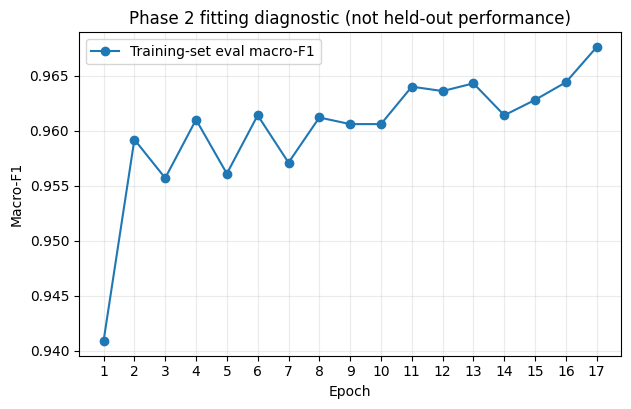

Final epoch: accuracy=0.9652, macro-F1=0.9676, loss=0.0771


In [ ]:
# Reconstruct the Phase-2 fitting curve from the latest console transcript.
pat = re.compile(r'\[phase2_final_C_e17_seed123\] epoch\s+(\d+)/17\s+train_loss=([0-9.]+) train_acc=([0-9.]+)\s+eval_loss=([0-9.]+) eval_acc=([0-9.]+) eval_macroF1=([0-9.]+)')
rows = [tuple(map(float, m.groups())) for m in pat.finditer(console)]
assert len(rows) == 17, f'Expected 17 Phase-2 epochs, found {len(rows)}'
epoch = [int(r[0]) for r in rows]
macro_f1 = [r[5] for r in rows]
plt.figure(figsize=(7,4.2))
plt.plot(epoch, macro_f1, marker='o', label='Training-set eval macro-F1')
plt.xlabel('Epoch'); plt.ylabel('Macro-F1')
plt.title('Phase 2 fitting diagnostic (not held-out performance)')
plt.xticks(epoch); plt.grid(alpha=.25); plt.legend(); plt.show()
print(f'Final epoch: accuracy={rows[-1][4]:.4f}, macro-F1={rows[-1][5]:.4f}, loss={rows[-1][3]:.4f}')

## 5. Validation model comparison

| Model | Mean val. macro-F1 | Std (3 seeds) | Params | MAC/window |
|---|---|---|---|---|
| A | 0.9890 | 0.0006 | 3,766 | 274,624 |
| B | 0.9813 | 0.0007 | 14,390 | 602,496 |
| C | **0.9898** | 0.0005 | 8,862 | 415,296 |

C wins under the predetermined selection rule and is the model carried forward. With only 3 seeds per
architecture, these standard deviations are not a basis for a statistical significance claim; they are
reported only to show the comparison is not obviously noise-dominated. Two observations are worth noting
without over-interpreting them: B underperforms A despite roughly 4x more parameters, suggesting its
extra capacity was not well used at this data scale; and A and C differ by only 0.0008 in mean validation
macro-F1 — comparable to, or smaller than, either model's own seed-to-seed spread. A is discussed further,
purely as a future embedded candidate, in Section 8.

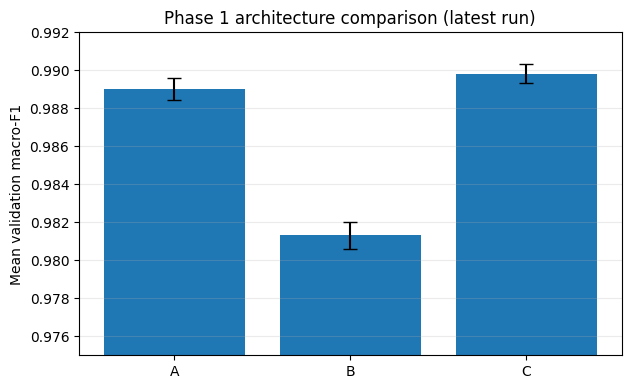

{'A': {'mean': 0.989, 'std': 0.0006, 'best_epoch': '3.0, 3.0, 3.0'},
 'B': {'mean': 0.9813, 'std': 0.0007, 'best_epoch': '2.0, 4.0, 2.0'},
 'C': {'mean': 0.9898, 'std': 0.0005, 'best_epoch': '1.0, 1.0, 2.0'}}

In [ ]:
# Latest Phase-1 summary is read from the same console transcript to avoid mixing older cached CSV values.
summary = {}
for m in re.finditer(r'^\s*([ABC]): mean=([0-9.]+)\s+std=([0-9.]+).*best_epoch=\[([^\]]+)\]', console, re.M):
    summary[m.group(1)] = {'mean': float(m.group(2)), 'std': float(m.group(3)), 'best_epoch': m.group(4)}
assert set(summary) == {'A','B','C'}
models = ['A','B','C']
means = [summary[m]['mean'] for m in models]
stds = [summary[m]['std'] for m in models]
plt.figure(figsize=(7,4.2))
plt.bar(models, means, yerr=stds, capsize=5)
plt.ylim(0.975, 0.992); plt.ylabel('Mean validation macro-F1')
plt.title('Phase 1 architecture comparison (latest run)')
plt.grid(axis='y', alpha=.25); plt.show()
summary

## 7. Historical official-test result (original 1-epoch protocol)

The original 1-epoch Phase-2 checkpoint was evaluated once on the 2,947-window official test set. These metrics document that earlier protocol and must not be attributed to the revised 17-epoch model:

| Metric | Value |
|---|---|
| Accuracy | 0.8870 |
| Macro-F1 | 0.8864 |
| Weighted-F1 | 0.8876 |

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| WALKING | 0.9886 | 0.8730 | 0.9272 | 496 |
| WALKING_UPSTAIRS | 0.9606 | 0.8811 | 0.9192 | 471 |
| WALKING_DOWNSTAIRS | 0.7812 | 0.9690 | 0.8650 | 420 |
| SITTING | 0.8299 | 0.7454 | 0.7854 | 491 |
| STANDING | 0.7889 | 0.8571 | 0.8216 | 532 |
| LAYING | 1.0000 | 1.0000 | 1.0000 | 537 |

See `results/historical_original_protocol/figures/confusion_matrix_final.png` for the full confusion matrix (counts and row-normalized).

**Failure analysis.** Of 333 total misclassifications: 58.9% occur within the static group
(SITTING/STANDING/LAYING), 39.3% within the dynamic group (the three walking variants), and only 1.8%
cross between the two groups. The dominant single failure mode is SITTING/STANDING confusion (122
SITTING->STANDING, 74 STANDING->SITTING) — these two postures produce very similar gravity-direction
signatures on a phone-mounted IMU and are frequently confused in raw-signal HAR work generally. The
secondary failure mode is between the walking variants, especially WALKING_DOWNSTAIRS being
over-predicted (59 WALKING and 55 WALKING_UPSTAIRS windows classified as WALKING_DOWNSTAIRS), consistent
with downstairs walking sharing much of its frequency content with the other gaits while carrying a
distinct (but here evidently insufficiently captured) vertical-impact signature. LAYING is classified
perfectly (F1 = 1.000) — its near-static, near-horizontal orientation is unambiguous relative to every
other class; this is a property of this test set's separability for this activity and should not be
read as a general claim that LAYING is trivially always distinguishable from every other posture.

The 1.8% cross-group error rate is a real, measured statistic about this 6-class model's confusion
pattern. It is suggestive that a coarse static/dynamic distinction may be easier than fine-grained
6-way classification, which motivates the wake-up framing in Section 8 — but it is not evidence that
a dedicated 2-class detector would achieve this error rate itself, since no such detector has been
trained or evaluated here.

### Historical confusion matrix

The figure below is **not newly generated for the 17-epoch checkpoint**. It belongs to the earlier one-epoch official-test evaluation and is retained only for provenance/failure analysis.

![Historical official-test confusion matrix](../results/historical_original_protocol/figures/confusion_matrix_final.png)

## 8. Generalization and limitations

**Historical validation-to-test gap.** Phase-1 C's mean validation macro-F1 was 0.9898; the original
1-epoch checkpoint's test macro-F1 was 0.8864. This comparison belongs to the earlier protocol, not the
revised 17-epoch model. Two plausible, untested contributing factors to that historical gap were:

- **Subject/domain variation.** The Phase-1 validation set (4 subjects) is small and may not represent
  the same range of gait/posture variation as the 9 official test subjects; a 4-subject validation
  estimate has limited power to detect this in advance.
- **The original one-epoch retraining budget.** The earlier rule used the mean *best-validation epoch*
  `[1,1,2]`, producing a one-epoch full-data run. Its training-set evaluation after that epoch was 0.9409
  macro-F1. This made undertraining a plausible concern. The revised protocol therefore uses the mean
  *actual Phase-1 training duration* `[17,17,18]` to define 17 epochs. This methodological change does not
  retroactively change or reinterpret the historical test score.

Other limitations of the experimental design:

- A single subject-held-out validation split (not cross-validation) means the architecture-selection
  signal itself rests on one particular 17/4 subject partition.
- Three seeds per architecture is a minimal, not a rigorous, basis for comparing architectures.
- The trained convolutions use symmetric ("same") padding, making the model non-causal — each feature
  depends on samples both before and after it in time, which matters for any future streaming redesign
  (Section 8) but does not affect the validity of the reported classification metrics.
- UCI HAR's presegmented, 50%-overlapping windows are a research-dataset convenience; a deployed system
  would need to decide how to window a continuous stream, which was not addressed here.
- No embedded benchmark, quantization experiment, or energy measurement was performed; Section 8's
  hardware-adjacent numbers are explicitly derived arithmetic, not measurements.

## 9. Streaming / embedded implications

*Measured* = obtained from this experiment. *Derived* = arithmetic on measured/architectural quantities.
*Hypothetical* = illustrative, not implemented or tested.

**Model C's compute/storage** (measured): 8,862 params, 34.62 KB fp32 weights, 415,296 MACs per 128-sample
window, local receptive field 60 samples (1.20 s), peak activation 12.00 KB (a Python/PyTorch
whole-window execution figure, not a streaming-implementation memory estimate — see below).

**Ordinary sliding-window rate** (derived): under UCI HAR's native 50%-overlap scheme (hop = 64 samples =
1.28 s), the classifier would run at 1/1.28 s = 0.781 classifications/s, i.e. 415,296/1.28 s = 324,450
MAC/s (0.324 MMAC/s). Raw six-channel input at 50 Hz is 300 values/s, or 1,200 B/s (9.6 kbps) at float32 —
an int16 sensor representation (4.8 kbps) is mentioned only as an illustrative alternative, not something
implemented here.

**Why this is not yet streaming.** The current implementation buffers a full 2.56 s window before running
any computation and reprocesses the shared half of every window from scratch on each hop. A genuinely
streaming implementation would instead maintain persistent state and update it as samples arrive,
producing lower and more predictable latency without repeating work on already-seen samples.

**Incremental-computation feasibility, by operation (analysis only, not implemented):** ordinary and
depthwise Conv1D map naturally onto a ring buffer holding the last `kernel-1` samples per channel;
pointwise (1x1) convolutions are memoryless in time; BatchNorm can, in principle, be folded into the
preceding convolution's weights ahead of time using its fixed running statistics; pooling reduces the
output rate but needs only one extra buffered sample; Global Average Pooling can become a running
sum-and-count accumulator rather than a stored feature map. None of these transformations exist in the
current training/evaluation code — they describe a future port, which would need to be validated against
the trained PyTorch model's output before being trusted.

**Overlap reuse.** Because consecutive windows share 64 of 128 samples, a persistent-buffer
implementation could in principle avoid recomputing convolutional features already computed for those
samples. This argument does not extend cleanly to the classification decision itself, since Global Average
Pooling aggregates over a window-specific feature map; and the model's non-causal padding means a
streaming buffer's edge behavior would differ from the current implementation's zero-padded edges, not
just its timing. Any streaming redesign would need sample-range-by-sample-range validation against the
frozen reference model before its outputs could be trusted to match.

**Wake-up interpretation.** The 1.8% cross-group error rate (Section 6) is consistent with a two-stage
design — an ultra-light detector distinguishing "static/irrelevant" from "dynamic/interesting" activity,
waking a larger classifier only when needed — being easier than full 6-way classification. This model was
trained and evaluated as a 6-class classifier, not as a binary detector, so this statistic motivates but
does not demonstrate a deployable wake-up stage; no energy or duty-cycle claim can be made without
measuring both a real activity duty cycle and the energy cost of each stage on target hardware.

**A vs. C, an embedded question, not a re-selection.** C is the model selected by the predetermined
validation-macro-F1 rule (Section 5) and the architecture used for the revised 17-epoch final checkpoint;
that selection is not being revisited. As a forward-looking embedded question: relative to C, A uses 57.5% fewer parameters
and 33.9% fewer MACs per window, for a mean validation macro-F1 difference of only 0.0008 (Section 5). For
a low-power wake-up role specifically, A's smaller compute and shorter receptive field make it worth
future investigation as a Pareto-efficient alternative — A has not been, and is not here, evaluated on the
official test set.

**Quantization** (derived storage arithmetic only): naive int8 storage (1 byte/parameter, ignoring
scale/zero-point metadata) gives 8.65 KB for C and 3.68 KB for A, a 4x reduction from float32 in both
cases. No accuracy, latency, or energy claim is made — quantization has not been performed.

**No hardware measurement of any kind** — cycles, DMA-compute overlap, SRAM traffic, energy, wake-up
latency, or an X-HEEP implementation — exists for this project. A conceptual mapping (sensor -> DMA/FIFO
-> chunk buffer -> incremental Conv1D pipeline -> incremental aggregation -> wake/classification decision
-> interrupt) is a plausible target for future work, not a benchmarked design.

## 10. Next steps

1. Implement equivalent NumPy/C streaming (ring-buffer) kernels for Model C's operations.
2. Verify streaming outputs against the frozen PyTorch reference, sample range by sample range.
3. Investigate causal vs. the current symmetric-padding behavior and its effect on alignment/latency.
4. Post-training int8 quantization, and separately quantization-aware training; measure real accuracy impact.
5. Train and evaluate a dedicated binary static-vs-dynamic (or event/no-event) wake-up objective directly.
6. Benchmark both A and C on target MCU hardware, without reopening the frozen model-selection process.
7. Measure real cycles, SRAM traffic, and energy per operation on that hardware.
8. Investigate overlapping convolution/activation compute with DMA sensor-chunk reception.
9. Profile to identify the actual bottleneck operation before assuming which one it is.
10. Consider a custom accelerator only after profiling shows a specific, measured bottleneck.

## 11. Conclusion

The development experiment selected Model C, an 8,862-parameter raw-IMU CNN, with mean subject-held-out
validation macro-F1 0.9898 across three seeds. Its Phase-1 runs stopped after 17, 17, and 18 epochs; their
rounded mean therefore defines a fixed 17-epoch final-training budget. This is deliberately different
from early stopping: Phase 2 uses all 21 development subjects and has no independent validation set, so
the epoch count is fixed before training rather than selected from training metrics or the official test.
The completed 17-epoch Phase-2 run reached 0.9652 accuracy and 0.9676 macro-F1 when evaluated on its own
training set and saved the final-epoch checkpoint successfully. These are fitting diagnostics, not
generalization estimates.

For provenance, the report retains the official-test result of an earlier one-epoch protocol: 88.70%
accuracy and 88.64% macro-F1 on 2,947 official test windows. Its errors were dominated by
SITTING/STANDING confusion and confusion among walking variants. Those test metrics must not be attributed
to the revised 17-epoch checkpoint. The revised experiment therefore provides a clean final-training
methodology and a compact model ready for evaluation, while keeping the historical test evidence clearly
separated. The compute, receptive-field, and error analyses motivate future streaming and wake-up work,
but no streaming implementation, quantized-accuracy result, MCU timing, or energy measurement is claimed.